In [2]:

import numpy as np
from itertools import product
from skimage import draw, transform

def circle(size, val=None, r_shrink=0):
    circle = np.zeros([size[0]+1, size[1]+1])
    rr, cc = draw.circle_perimeter(
        size[0]//2, size[1]//2,
        radius=size[0]//2 - r_shrink,
        shape=[size[0]+1, size[1]+1],
    )
    if val is None:
        circle[rr, cc] = np.random.uniform(size=circle.shape)[rr, cc]
    else:
        circle[rr, cc] = val
    circle = transform.resize(circle, size, order=0)
    return circle

def show_kernel(kernel, label=True, digits=None, text_size=28):
    # Format kernel
    kernel = np.array(kernel)
    if digits is not None:
        kernel = kernel.round(digits)

    # Plot kernel
    cmap = plt.get_cmap('Blues_r')
    plt.imshow(kernel, cmap=cmap)
    rows, cols = kernel.shape
    thresh = (kernel.max()+kernel.min())/2
    # Optionally, add value labels
    if label:
        for i, j in product(range(rows), range(cols)):
            val = kernel[i, j]
            color = cmap(0) if val > thresh else cmap(255)
            plt.text(j, i, val, 
                     color=color, size=text_size,
                     horizontalalignment='center', verticalalignment='center')
    plt.xticks([])
    plt.yticks([])

def show_extraction(image,
                    kernel,
                    conv_stride=1,
                    conv_padding='valid',
                    activation='relu',
                    pool_size=2,
                    pool_stride=2,
                    pool_padding='same',
                    figsize=(10, 10),
                    subplot_shape=(2, 2),
                    ops=['Input', 'Filter', 'Detect', 'Condense'],
                    gamma=1.0):
    # Create Layers
    model = tf.keras.Sequential([
                    tf.keras.layers.Conv2D(
                        filters=1,
                        kernel_size=kernel.shape,
                        strides=conv_stride,
                        padding=conv_padding,
                        use_bias=False,
                        input_shape=image.shape,
                    ),
                    tf.keras.layers.Activation(activation),
                    tf.keras.layers.MaxPool2D(
                        pool_size=pool_size,
                        strides=pool_stride,
                        padding=pool_padding,
                    ),
                   ])

    layer_filter, layer_detect, layer_condense = model.layers
    kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
    layer_filter.set_weights([kernel])

    # Format for TF
    image = tf.expand_dims(image, axis=0)
    image = tf.image.convert_image_dtype(image, dtype=tf.float32) 
    
    # Extract Feature
    image_filter = layer_filter(image)
    image_detect = layer_detect(image_filter)
    image_condense = layer_condense(image_detect)
    
    images = {}
    if 'Input' in ops:
        images.update({'Input': (image, 1.0)})
    if 'Filter' in ops:
        images.update({'Filter': (image_filter, 1.0)})
    if 'Detect' in ops:
        images.update({'Detect': (image_detect, gamma)})
    if 'Condense' in ops:
        images.update({'Condense': (image_condense, gamma)})
    
    # Plot
    plt.figure(figsize=figsize)
    for i, title in enumerate(ops):
        image, gamma = images[title]
        plt.subplot(*subplot_shape, i+1)
        plt.imshow(tf.image.adjust_gamma(tf.squeeze(image), gamma))
        plt.axis('off')
        plt.title(title)

# Введение #

В предыдущих двух уроках мы узнали о трёх операциях, которые выполняют извлечение признаков из изображения:
1. *фильтрация* с помощью **свёрточного** слоя
2. *обнаружение* с помощью активации **ReLU**
3. *конденсация* с помощью слоя **максимального пулинга**

У операций свёртки и пулинга есть общая черта: обе выполняются через **скользящее окно**. При свёртке это «окно» задаётся размерами ядра — параметром `kernel_size`. При пулинге это окно пулинга, задаваемое параметром `pool_size`.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/LueNK6b.gif" width=400 alt="Двумерное скользящее окно.">
</figure>

Есть два дополнительных параметра, влияющих как на свёрточные слои, так и на слои пулинга: это `strides` (шаг) окна и использование `padding` (дополнения) на краях изображения. Параметр `strides` определяет, насколько далеко окно перемещается на каждом шаге, а параметр `padding` описывает, как мы обрабатываем пиксели на границах входа.

С этими двумя параметрами определение двух слоёв выглядит так:

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64,
                  kernel_size=3,
                  strides=1,
                  padding='same',
                  activation='relu'),
    layers.MaxPool2D(pool_size=2,
                     strides=1,
                     padding='same')
    # More layers follow
])

# Шаг (Stride) #

Расстояние, на которое перемещается окно на каждом шаге, называется **шагом (stride)**. Нам нужно указать шаг по обоим измерениям изображения: один для движения слева направо и один для движения сверху вниз. Эта анимация показывает `strides=(2, 2)` — перемещение на 2 пикселя на каждом шаге.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/Tlptsvt.gif" width=400 alt="Скользящее окно с шагом (2, 2).">
</figure>

Какой эффект даёт шаг? Когда шаг в любом направлении больше 1, скользящее окно будет пропускать некоторые пиксели входа на каждом шаге.

Поскольку мы хотим получать высококачественные признаки для классификации, свёрточные слои чаще всего имеют `strides=(1, 1)`. Увеличение шага означает, что мы теряем потенциально ценную информацию в нашей сводке. Однако слои максимального пулинга почти всегда имеют значения шага больше 1, например `(2, 2)` или `(3, 3)`, но не больше самого окна.

Наконец, обратите внимание: когда значение `strides` одинаково в обоих направлениях, достаточно указать только это число; например, вместо `strides=(2, 2)` можно использовать `strides=2`.

# Дополнение (Padding) #

При выполнении вычислений со скользящим окном возникает вопрос: что делать на границах входных данных? Если окно остаётся полностью внутри изображения, оно никогда не будет располагаться ровно над граничными пикселями так, как это происходит для всех остальных пикселей. Поскольку мы обрабатываем не все пиксели одинаково, может ли это быть проблемой?

То, как свёртка обрабатывает граничные значения, определяется её параметром `padding`. В TensorFlow есть два варианта: `padding='same'` или `padding='valid'`. У каждого есть свои компромиссы.

Когда мы устанавливаем `padding='valid'`, окно свёртки остаётся полностью внутри входных данных. Недостаток в том, что выход сжимается (теряет пиксели) и сжимается сильнее для больших ядер. Это ограничивает количество слоёв, которые может содержать сеть, особенно при малом размере входных данных.

Альтернатива — использовать `padding='same'`. Суть в том, чтобы **дополнить** входные данные нулями по краям, используя ровно столько нулей, чтобы размер выхода был *таким же*, как размер входа. Однако это может привести к размытию влияния пикселей на границах. Анимация ниже показывает скользящее окно с дополнением `'same'`.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/RvGM2xb.gif" width=400 alt="Иллюстрация нулевого дополнения (same).">
</figure>

Модель VGG, которую мы рассматривали, использует дополнение `same` для всех своих свёрточных слоёв. Большинство современных свёрточных сетей используют некоторую комбинацию обоих вариантов. (Ещё один параметр для настройки!)

# Пример — исследование скользящих окон #

Чтобы лучше понять влияние параметров скользящего окна, полезно понаблюдать за извлечением признаков на изображении с низким разрешением, чтобы мы могли видеть отдельные пиксели. Давайте просто посмотрим на простой круг.

Следующая скрытая ячейка создаст для нас изображение и ядро.

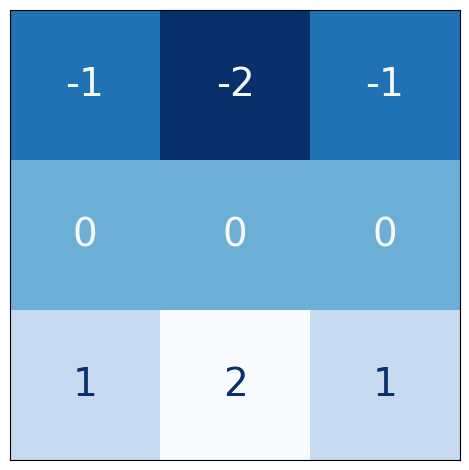

In [4]:

import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

image = circle([64, 64], val=1.0, r_shrink=3)
image = tf.reshape(image, [*image.shape, 1])
# Bottom sobel
kernel = tf.constant(
    [[-1, -2, -1],
     [0, 0, 0],
     [1, 2, 1]],
)

show_kernel(kernel)

Архитектура VGG довольно проста. Она использует свёртку с шагом 1 и максимальный пулинг с окнами $2 \times 2$ и шагом 2. Мы включили функцию в служебный скрипт `visiontools`, которая покажет нам все шаги.

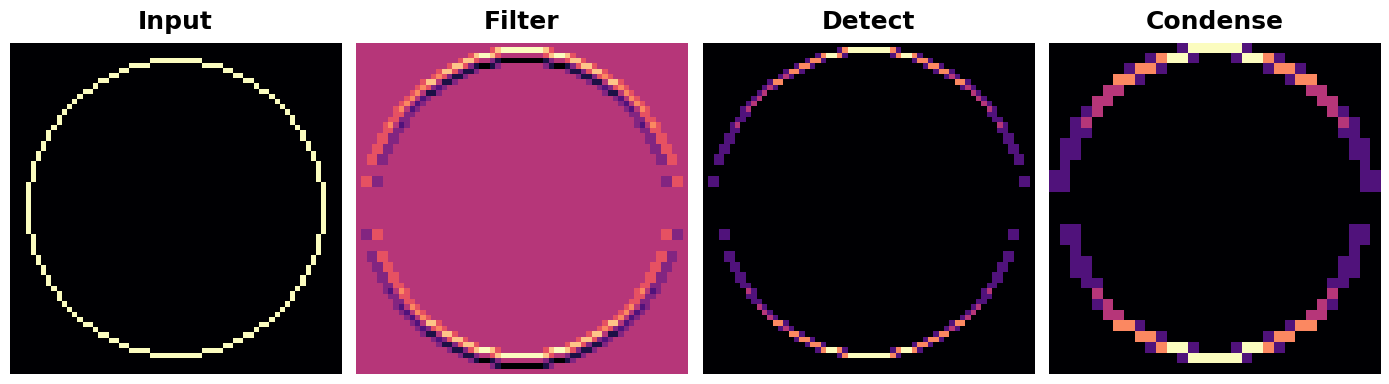

In [5]:
show_extraction(
    image, kernel,

    # Window parameters
    conv_stride=1,
    pool_size=2,
    pool_stride=2,

    subplot_shape=(1, 4),
    figsize=(14, 6),
)

И это работает довольно хорошо! Ядро было разработано для обнаружения горизонтальных линий, и мы видим, что в результирующей карте признаков наиболее горизонтальные части входа получают наибольшую активацию.

Что произойдёт, если мы изменим шаг свёртки на 3?

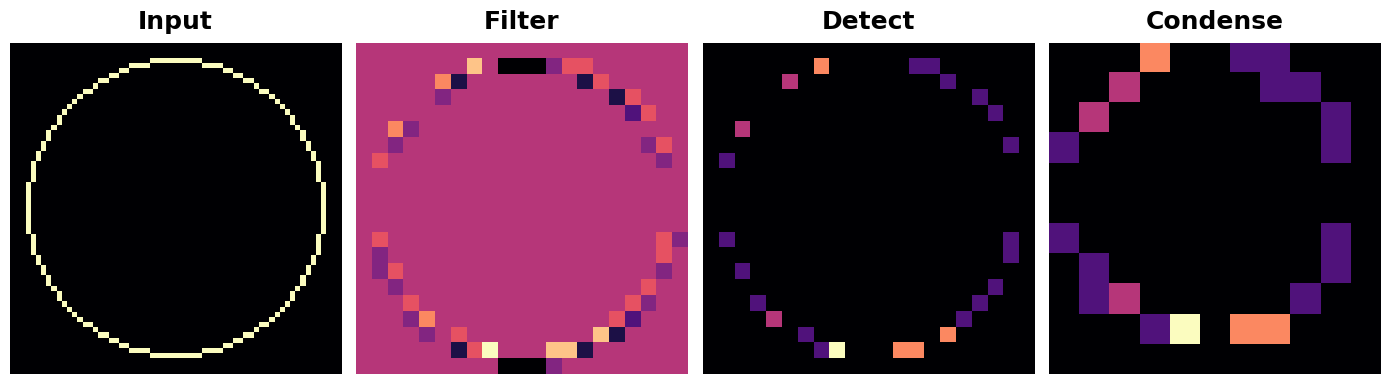

In [6]:
show_extraction(
    image, kernel,

    # Window parameters
    conv_stride=3,
    pool_size=2,
    pool_stride=2,

    subplot_shape=(1, 4),
    figsize=(14, 6),    
)

Похоже, это снижает качество извлечённого признака. Наш входной круг довольно «мелкодетализирован» — его ширина всего 1 пиксель. Свёртка с шагом 3 слишком груба, чтобы создать из него хорошую карту признаков.

Иногда модель использует свёртку с большим шагом в своём начальном слое. Обычно это сочетается с большим ядром. Например, модель ResNet50 использует ядра $7 \times 7$ с шагом 2 в своём первом слое. Это ускоряет создание крупномасштабных признаков без потери слишком большого объёма информации из входных данных.

# Заключение #

В этом уроке мы рассмотрели характерное вычисление, общее как для свёртки, так и для пулинга: **скользящее окно** и параметры, влияющие на его поведение в этих слоях. Такой стиль оконных вычислений во многом определяет характер свёрточных сетей и является неотъемлемой частью их функционирования.

# Ваша очередь #

Переходите к [**Упражнению**](https://www.kaggle.com/kernels/fork/12400209), где вы исследуете скользящие окна, узнаете, как *стэкинг* свёрточных слоёв может увеличить эффективный размер окна, а также как свёртка может использоваться с *одномерными* данными, например с временными рядами.

---




*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*